In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize (VERY IMPORTANT)
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


In [5]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - accuracy: 0.4359 - loss: 1.5398 - val_accuracy: 0.5334 - val_loss: 1.2839
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.5857 - loss: 1.1682 - val_accuracy: 0.6152 - val_loss: 1.0948
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6382 - loss: 1.0188 - val_accuracy: 0.6550 - val_loss: 0.9965
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.6764 - loss: 0.9173 - val_accuracy: 0.6742 - val_loss: 0.9446
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 38ms/step - accuracy: 0.7044 - loss: 0.8469 - val_accuracy: 0.6844 - val_loss: 0.9201
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - accuracy: 0.7246 - loss: 0.7852 - val_accuracy: 0.6892 - val_loss: 0.9034
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.7430 - loss: 0.7350 - val_accuracy: 0.6957 - val_loss: 0.8801
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.7572 -

In [8]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1000
           1       0.81      0.84      0.82      1000
           2       0.57      0.62      0.60      1000
           3       0.56      0.49      0.52      1000
           4       0.64      0.72      0.68      1000
           5       0.63      0.64      0.63      1000
           6       0.75      0.82      0.78      1000
           7       0.79      0.73      0.76      1000
           8       0.84      0.80      0.82      1000
           9       0.81      0.77      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



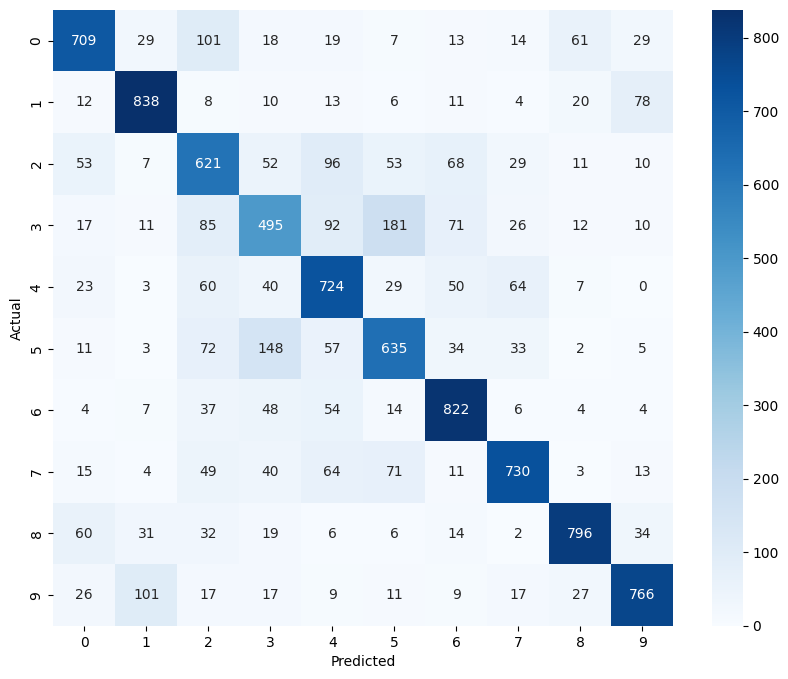

In [9]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

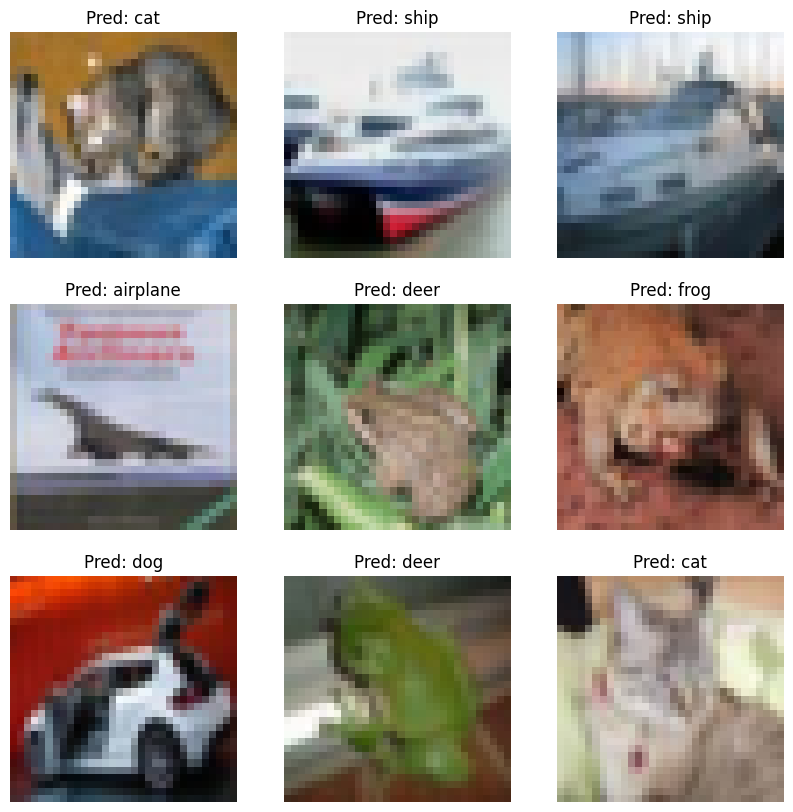

In [10]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()

In [11]:
def build_model(activation):
    model = tf.keras.Sequential([

        layers.Conv2D(32, (3,3), activation=activation, input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation=activation),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation=activation),

        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [12]:
model_sigmoid = build_model('sigmoid')
history_sigmoid = model_sigmoid.fit(x_train, y_train, epochs=10,
                                   validation_data=(x_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.1869 - loss: 2.1499 - val_accuracy: 0.3249 - val_loss: 1.8720
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 39ms/step - accuracy: 0.3726 - loss: 1.7369 - val_accuracy: 0.4216 - val_loss: 1.6148
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4324 - loss: 1.5807 - val_accuracy: 0.4612 - val_loss: 1.5079
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4666 - loss: 1.4858 - val_accuracy: 0.4761 - val_loss: 1.4608
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4952 - loss: 1.4133 - val_accuracy: 0.4943 - val_loss: 1.4115
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.5140 - loss: 1.3563 - val_accuracy: 0.5075 - val_loss: 1.3840
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.5348 - loss: 1.3017 - val_accuracy: 0.5226 - val_loss: 1.3296
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.5544 -

In [25]:
ys_pred = model_sigmoid.predict(x_test)
ys_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, ys_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1000
           1       0.62      0.72      0.67      1000
           2       0.58      0.33      0.42      1000
           3       0.45      0.36      0.40      1000
           4       0.58      0.35      0.43      1000
           5       0.42      0.60      0.49      1000
           6       0.59      0.70      0.64      1000
           7       0.61      0.63      0.62      1000
           8       0.68      0.56      0.62      1000
           9       0.49      0.75      0.59      1000

    accuracy                           0.55     10000
   macro avg       0.57      0.55      0.55     10000
weighted avg       0.57      0.55      0.55     10000



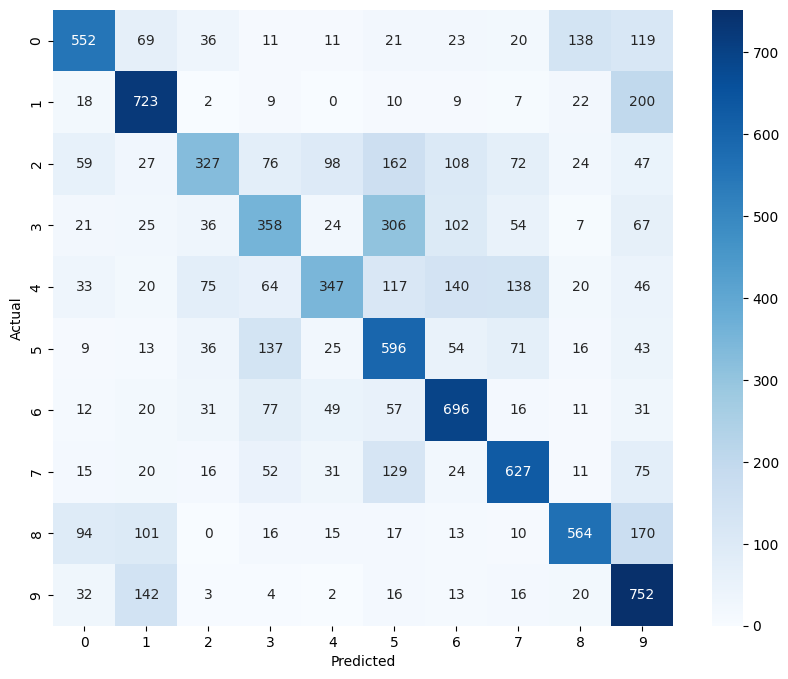

In [26]:
cm = confusion_matrix(y_test, ys_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
model_tanh = build_model('tanh')
history_tanh = model_tanh.fit(x_train, y_train, epochs=10,
                             validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.5034 - loss: 1.4041 - val_accuracy: 0.5942 - val_loss: 1.1647
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6074 - loss: 1.1168 - val_accuracy: 0.6274 - val_loss: 1.0875
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.6426 - loss: 1.0275 - val_accuracy: 0.6290 - val_loss: 1.0955
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6669 - loss: 0.9614 - val_accuracy: 0.6498 - val_loss: 1.0105
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6847 - loss: 0.9085 - val_accuracy: 0.6532 - val_loss: 0.9939
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7009 - loss: 0.8612 - val_accuracy: 0.6631 - val_loss: 0.9894
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.7117 - loss: 0.8251 - val_accuracy: 0.6651 - val_loss: 0.9859
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.7276 -

In [27]:
yt_pred = model_sigmoid.predict(x_test)
yt_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, yt_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1000
           1       0.62      0.72      0.67      1000
           2       0.58      0.33      0.42      1000
           3       0.45      0.36      0.40      1000
           4       0.58      0.35      0.43      1000
           5       0.42      0.60      0.49      1000
           6       0.59      0.70      0.64      1000
           7       0.61      0.63      0.62      1000
           8       0.68      0.56      0.62      1000
           9       0.49      0.75      0.59      1000

    accuracy                           0.55     10000
   macro avg       0.57      0.55      0.55     10000
weighted avg       0.57      0.55      0.55     10000



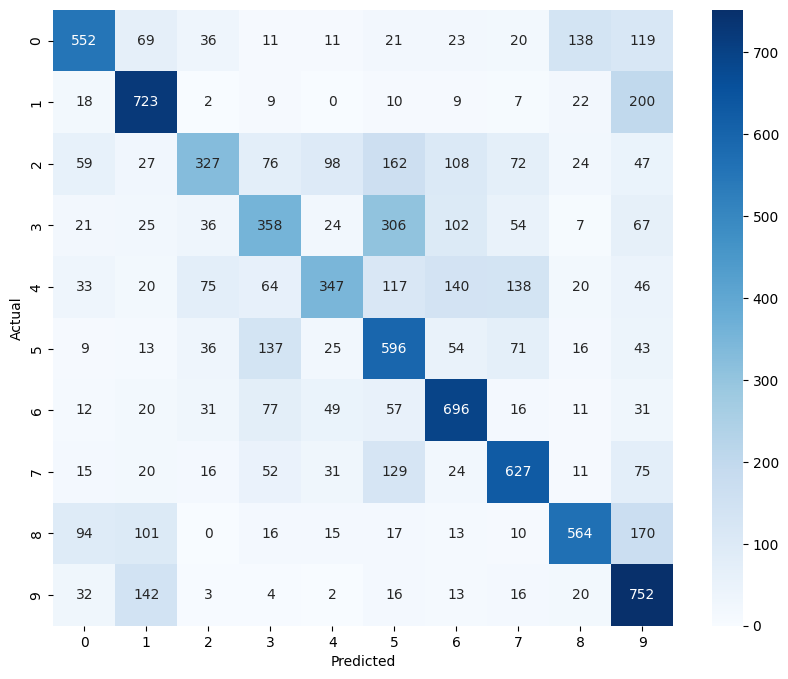

In [28]:
cm = confusion_matrix(y_test, yt_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

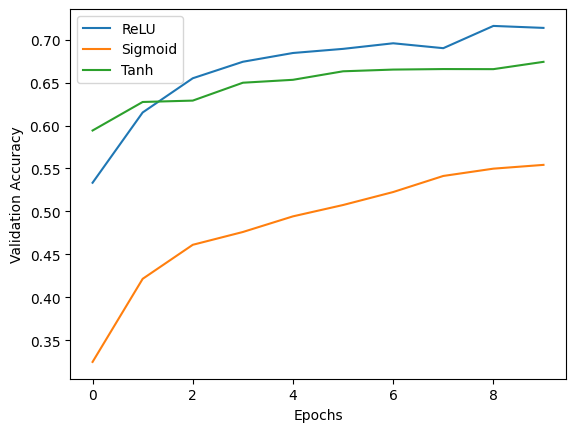

In [14]:
plt.plot(history.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [17]:
print("Sigmoid Accuracy:", model_sigmoid.evaluate(x_test, y_test)[1])

print("ReLU Accuracy:", model.evaluate(x_test, y_test)[1])

print("Tanh Accuracy:", model_tanh.evaluate(x_test, y_test)[1])


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5542 - loss: 1.2671
Sigmoid Accuracy: 0.5541999936103821
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7136 - loss: 0.8720
ReLU Accuracy: 0.7135999798774719
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6741 - loss: 0.9924
Tanh Accuracy: 0.6740999817848206


In [21]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Flatten true labels
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step


In [22]:
from sklearn.metrics import classification_report

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

report = classification_report(y_true, y_pred_classes, target_names=class_names)

print(report)

              precision    recall  f1-score   support

    airplane       0.76      0.71      0.73      1000
  automobile       0.81      0.84      0.82      1000
        bird       0.57      0.62      0.60      1000
         cat       0.56      0.49      0.52      1000
        deer       0.64      0.72      0.68      1000
         dog       0.63      0.64      0.63      1000
        frog       0.75      0.82      0.78      1000
       horse       0.79      0.73      0.76      1000
        ship       0.84      0.80      0.82      1000
       truck       0.81      0.77      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000

